In [1]:
import numpy as np
import scipy as sp 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
import qiskit as qk
from math import gcd, ceil, log2
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit_aer import AerSimulator

# Qiskit visualization libraries
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

To implement QPE we need to build our oracle. Qiskit supports arbitrary unitary gates given a matrix, so we can build our oracle as a matrix and then convert it to a gate. To test our assumption we will also need to find what r is for our choice of x and N so we have a function to do this. 

We have a function that builds our circuit for QPE and uses the work register input 1 and measures the counting register only since we are trying to validate the lower bound we found in part (d). Lasty, we build a function that runs our circuit and returns the probability of measuring the correct answer. We can validate this over a range of counting register sizes to see that the lower bound is still respected for different values of n. 

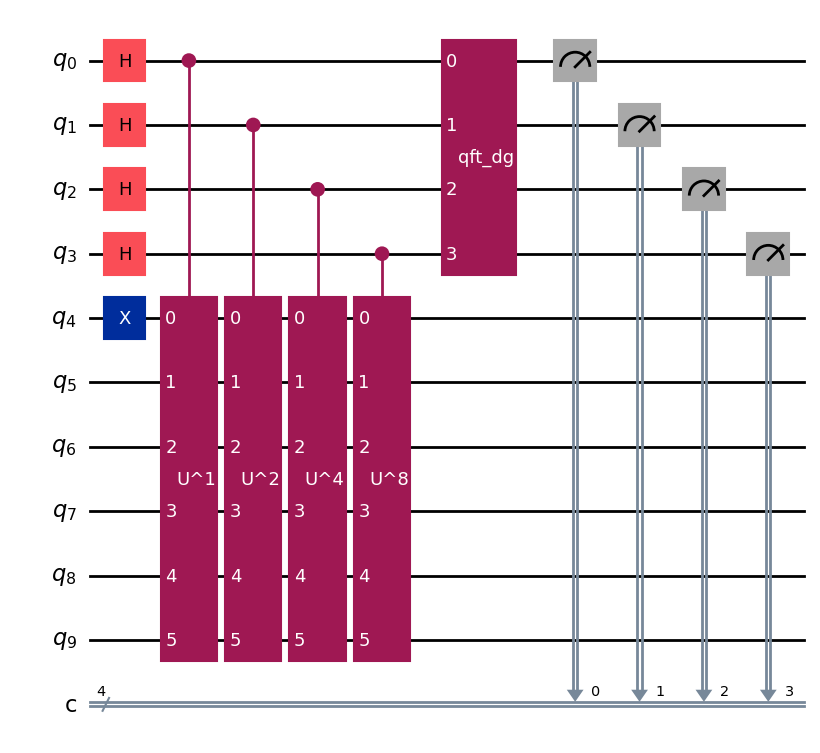


 Chosen x=2, N=35, order r=12
Empirical success probability at n=4: 0.8757
Is success probability > 4/pi^2? Yes
Top outcomes (bitstring, phase_hat, inferred s/r, probability):
0100 -> 0.250000, 3/12, p=0.1047 
0000 -> 0.000000, 0/12, p=0.0959 
1000 -> 0.500000, 6/12, p=0.0945 
1100 -> 0.750000, 9/12, p=0.0925 
1001 -> 0.562500, 7/12, p=0.0701 
1111 -> 0.937500, 11/12, p=0.0657 
1011 -> 0.687500, 8/12, p=0.0635 
0101 -> 0.312500, 4/12, p=0.0603 
1101 -> 0.812500, 10/12, p=0.0598 
0111 -> 0.437500, 5/12, p=0.0586 


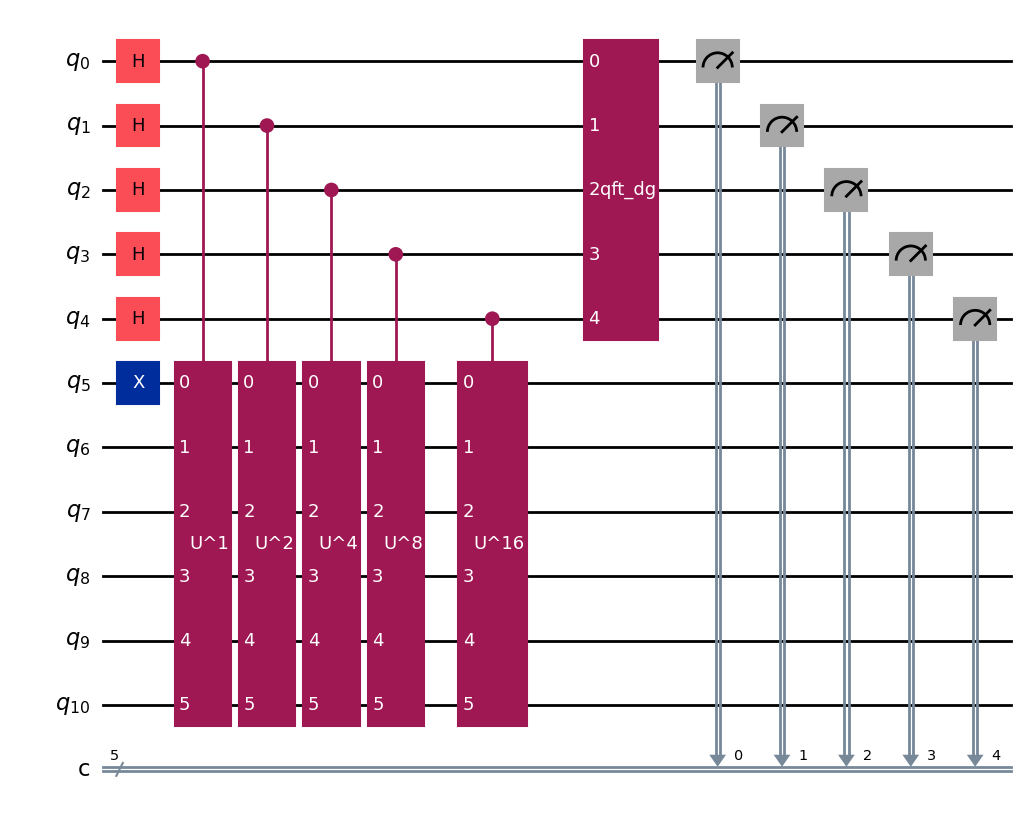


 Chosen x=2, N=35, order r=12
Empirical success probability at n=5: 0.8137
Is success probability > 4/pi^2? Yes
Top outcomes (bitstring, phase_hat, inferred s/r, probability):
01000 -> 0.250000, 3/12, p=0.0994 
10000 -> 0.500000, 6/12, p=0.0886 
00000 -> 0.000000, 0/12, p=0.0862 
11000 -> 0.750000, 9/12, p=0.0815 
10101 -> 0.656250, 8/12, p=0.0671 
11011 -> 0.843750, 10/12, p=0.0640 
10011 -> 0.593750, 7/12, p=0.0588 
11101 -> 0.906250, 11/12, p=0.0562 
01101 -> 0.406250, 5/12, p=0.0554 
00011 -> 0.093750, 1/12, p=0.0527 


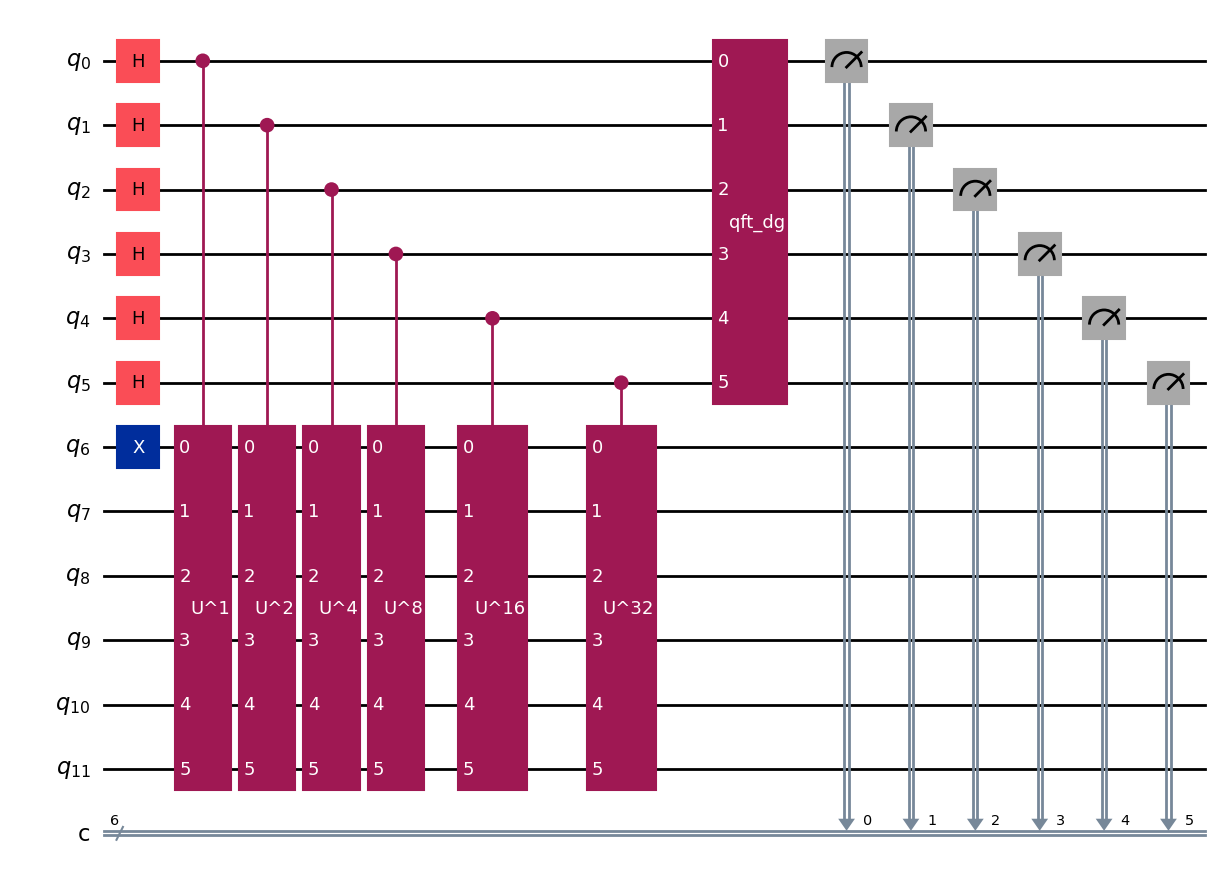


 Chosen x=2, N=35, order r=12
Empirical success probability at n=6: 0.7932
Is success probability > 4/pi^2? Yes
Top outcomes (bitstring, phase_hat, inferred s/r, probability):
010000 -> 0.250000, 3/12, p=0.0964 
000000 -> 0.000000, 0/12, p=0.0852 
100000 -> 0.500000, 6/12, p=0.0847 
110000 -> 0.750000, 9/12, p=0.0796 
100101 -> 0.578125, 7/12, p=0.0645 
111011 -> 0.921875, 11/12, p=0.0625 
101011 -> 0.671875, 8/12, p=0.0581 
110101 -> 0.828125, 10/12, p=0.0547 
010101 -> 0.328125, 4/12, p=0.0544 
001011 -> 0.171875, 2/12, p=0.0515 


In [ ]:
#function to find the order since we need this to know what r is. 
def multiplicative_order(x, N):
    """Smallest r > 0 such that x^r = 1 mod N."""
    r = 1
    val = x % N
    while val != 1:
        val = (val * x) % N
        r += 1
    return r

#matrix that implement's our oracle 
def Ux_matrix(x, N, m):
    """Matrix for U_x|y> = |x y mod N> on y < N"""
    dim = 2**m
    U = np.zeros((dim, dim), dtype=complex)
    for y in range(dim):
        target = (x * y) % N if y < N else y
        U[target, y] = 1.0
    return U

# function that builds our circuit for QPE with work input |1> and measures counting register only.
def QPE_circ(x, N, n_count):
    """Build QPE circuit with work input |1>; measure counting register only."""
    if x >= N:
        raise ValueError("Need x < N.")

    r = multiplicative_order(x, N)
    m = ceil(log2(N))
    U = Ux_matrix(x, N, m)

    n_total = n_count + m
    qc = QuantumCircuit(n_total, n_count)

    count_qubits = list(range(n_count))
    work_qubits = list(range(n_count, n_total))

    #prepare work register in |1> state (little-endian convention).
    qc.x(work_qubits[0])

    # apply multiplicity controlled Ux.
    qc.h(count_qubits)
    for j in range(n_count):
        U_pow = np.linalg.matrix_power(U, 2**j)
        cU = UnitaryGate(U_pow, label=f"U^{2**j}").control(1)
        qc.append(cU, [count_qubits[j]] + work_qubits)

    #inverse QFT on counting register and measure. 
    qc.append(QFTGate(n_count).inverse(), count_qubits)
    qc.measure(count_qubits, range(n_count))
    return qc, r, m

#used to compute the distance between the measured phase and the nearest eigenphase s/r. 
def phase_distance(a, b):
    """Distance between phases a and b in [0, 1)."""
    d = abs(a - b) % 1.0
    return min(d, 1.0 - d)


def inferred_s_from_phase(phase_hat, r):
    """Infer nearest s so that s/r is nearest to phase_hat."""
    return int(np.round(r * phase_hat)) % r


def sucecess_from_counts(counts, n_count, r):
    """Empirical success probability

    A shot is successful if the measured phase is within 1/2^(n+1)
    of some eigenphase s/r (with s inferred by nearest fraction).
    """
    threshold = 1 / (2 ** (n_count + 1))
    total = sum(counts.values())
    good = 0

    for bitstr, c in counts.items():
        k = int(bitstr, 2)
        phase_hat = k / (2**n_count)
        s_hat = inferred_s_from_phase(phase_hat, r)
        target = s_hat / r
        if phase_distance(phase_hat, target) <= threshold:
            good += c

    return good / total if total else 0.0


def run_QPE(x, N, n_count=6, shots=4096, seed=7):
    """Build and run QPE with work input |1>; return measured counts and metrics."""
    qc, r, m = QPE_circ(x, N, n_count)

    sim = AerSimulator()
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=shots, seed_simulator=seed).result()
    counts = result.get_counts()

    success_p = sucecess_from_counts(counts, n_count, r)

    return (success_p, counts)


x = 2
N = 35
shots = 4096

for n_count in [4, 5, 6, 7]:
    #visulize circuit
    qc = QPE_circ(x,N, n_count=n_count)[0]
    display(qc.draw('mpl'))
    # Single run: counts after QPE with work input |1>
    output = run_QPE(x, N, n_count=n_count, shots=shots, seed=21)
    r = multiplicative_order(x, N)

    print(f"\n Chosen x={x}, N={N}, order r={r}")
    print(f"Empirical success probability at n={n_count}: {output[0]:.4f}")
    #bool check if the success probability is above 0.5, which is a common threshold for success in quantum algorithms.
    print(f"Is success probability > 4/pi^2? {'Yes' if output[0] > 4/(np.pi**2) else 'No'}")

# Show top measured outcomes and inferred s/r.
    top_counts = sorted(output[1].items(), key=lambda kv: kv[1], reverse=True)[:10]
    print("Top outcomes (bitstring, phase_hat, inferred s/r, probability):")
    for bitstr, c in top_counts:
        phase_hat = int(bitstr, 2) / (2**n_count)
        s_hat = inferred_s_from_phase(phase_hat, r)
        print(f"{bitstr} -> {phase_hat:.6f}, {s_hat}/{r}, p={c/shots:.4f} ")


We can see here from our resutls that each case respects our theoretical lower bound of 4/pi^2, which is approximately 0.4053. This means that even with a small number of counting qubits (n=4), we are still able to achieve a success probability that is above this threshold, confirming the theoretical predictions for the performance of the QPE algorithm in this context.